# Why do we even dropout layers and how does it work in anns' ?
Dropout is a regularization technique for reducing overfitting in artificial neural networks by preventing complex co-adaptations on training data. The technique consists of randomly setting the inputs and/or outputs of neurons to zero. It is performed during the training process of a neural network, not during inference.


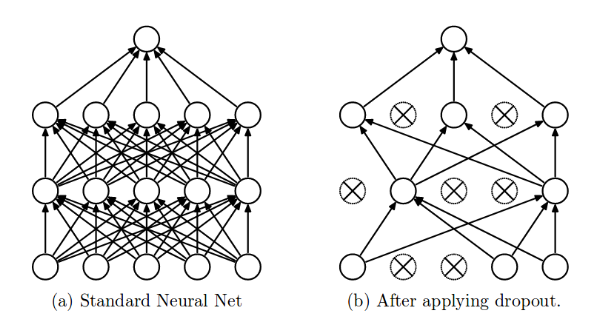

This can be correlated with random forest algorithm in machine learning where we train hundreds of tree based of randomly selecting columns , rows or both to form decision tree and then predicting using crowd's wisdom

In [41]:
# First import necessary libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

from sklearn.model_selection import train_test_split

import tensorflow 
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout,Dense,Input
from tensorflow.keras.optimizers import Adam

In [42]:
# Load the artificial dataset
df = pd.read_csv('artificial-dataset-classification.csv')

In [43]:
df.head() # Skim the head

,Feature_1,Feature_2,Target
0,-0.158986,0.423977,1
1,-0.347926,0.470760,1
2,-0.504608,0.353801,1
3,-0.596774,0.114035,1
4,-0.518433,-0.172515,1


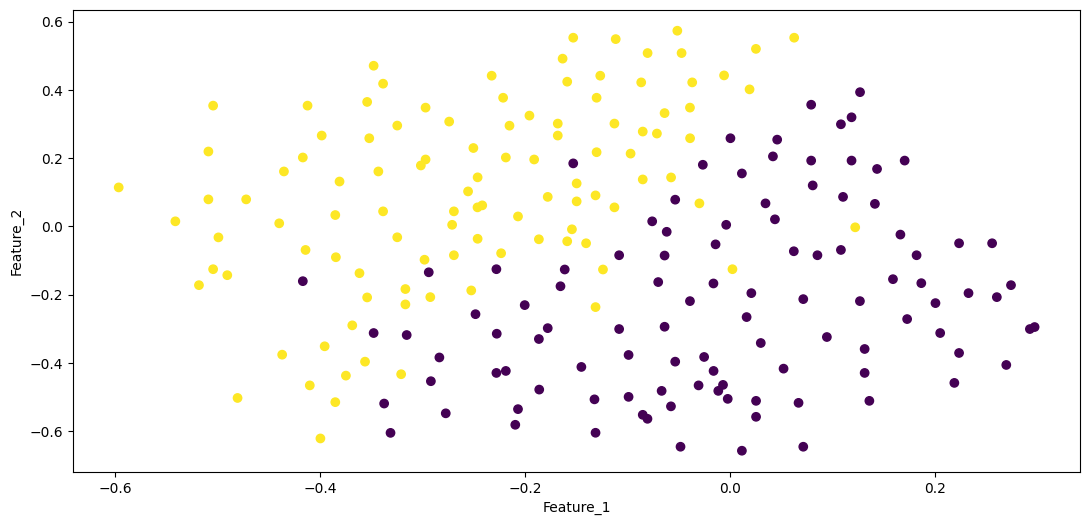

In [44]:
plt.figure(figsize=(13,6))
plt.scatter(df.iloc[:,0],df.iloc[:,1],c=df.iloc[:,-1])
plt.xlabel('Feature_1')
plt.ylabel('Feature_2')
plt.show()

In [45]:
# Now splitting the dataset into X and y 
X,y = df.iloc[:,:-1],df.iloc[:,-1]

In [46]:
# Splitting the dataset
X_train ,X_test ,y_train ,y_test = train_test_split(
                                                        X,y,
                                                        test_size = 0.2,
                                                        random_state = 9
)

In [47]:
# Our model will have hidden layers as relu and the final ouptut layer will have the activation function as sigmoid
# And we will be using binary_crossentropy as loss function with adam as optimizer with the learning rate of 0.1 
# Now commencing the creation of model

In [48]:
model = Sequential()
model.add(Input(shape=(X.shape[1],)))
model.add(Dense(128,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [49]:
# Now let's skim the summary to know what amount of parameters we are dealing with
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
# We will explicitly pass adam this time with a learning rate of 0.1
adam = Adam(learning_rate=0.1)

In [51]:
# Now let's compile the model
model.compile(loss='binary_crossentropy',optimizer=adam,metrics=['accuracy'])

In [53]:
# Now lets run the model
history = model.fit(X_train,y_train,epochs=500,validation_data=(X_test,y_test),verbose=1)

Epoch 1/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.9048 - loss: 0.1959 - val_accuracy: 0.8140 - val_loss: 0.7284
Epoch 2/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9405 - loss: 0.1479 - val_accuracy: 0.8372 - val_loss: 0.6293
Epoch 3/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9405 - loss: 0.1614 - val_accuracy: 0.8372 - val_loss: 0.6544
Epoch 4/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9226 - loss: 0.1581 - val_accuracy: 0.8372 - val_loss: 0.7239
Epoch 5/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9464 - loss: 0.1322 - val_accuracy: 0.8372 - val_loss: 0.7115
Epoch 6/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9405 - loss: 0.1560 - val_accuracy: 0.8140 - val_loss: 0.6831
Epoch 7/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9286 - loss: 0.1533 - val_accuracy: 0.8605 - val_loss: 0.8162
Epoch 8/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9464 - loss: 0.1450 - val_accuracy: 0.8372 - val_loss

28125/28125 ━━━━━━━━━━━━━━━━━━━━ 77s 3ms/step


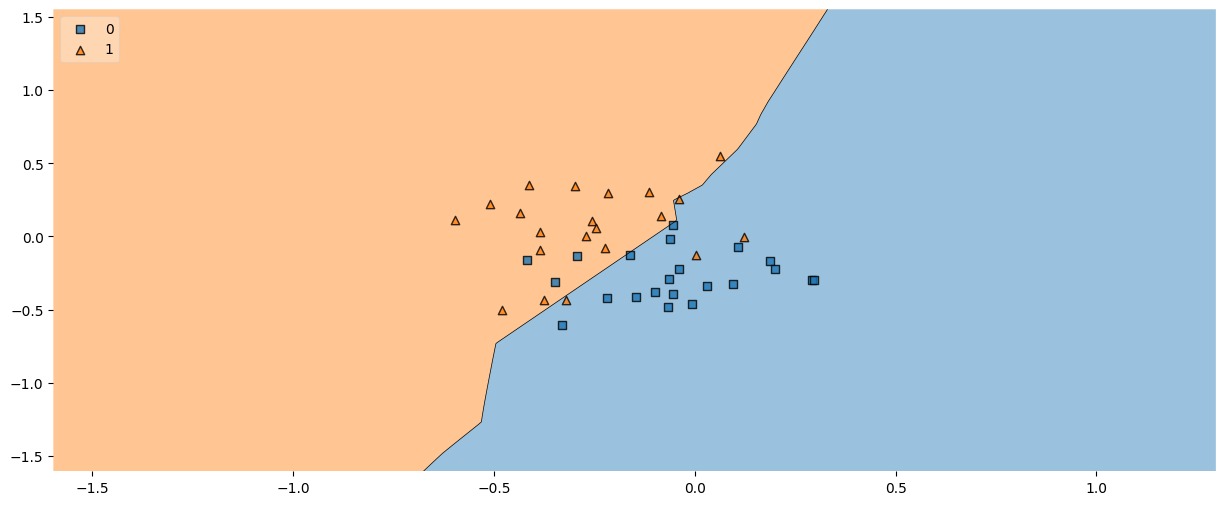

In [55]:
# Now let's checkout the model performance by plotting it's boundary using plot_decision_regions
plt.figure(figsize=(15,6))
plot_decision_regions(X_test.to_numpy(),y_test.to_numpy(),clf=model,legend=2)
plt.show()

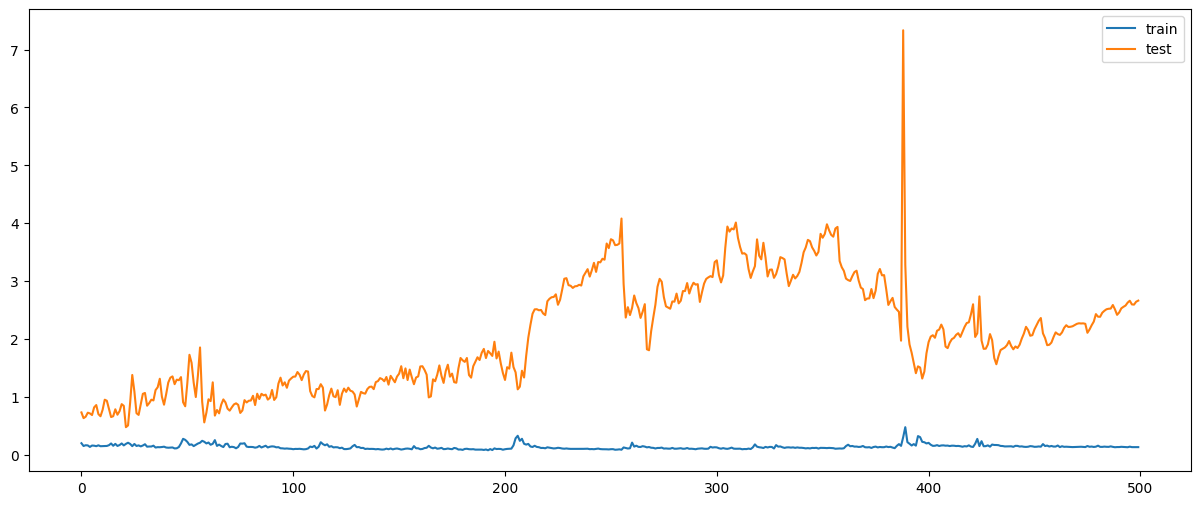

In [58]:
# Also now let's plot the loss and val_loss to understand what happened
plt.figure(figsize=(15,6))
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

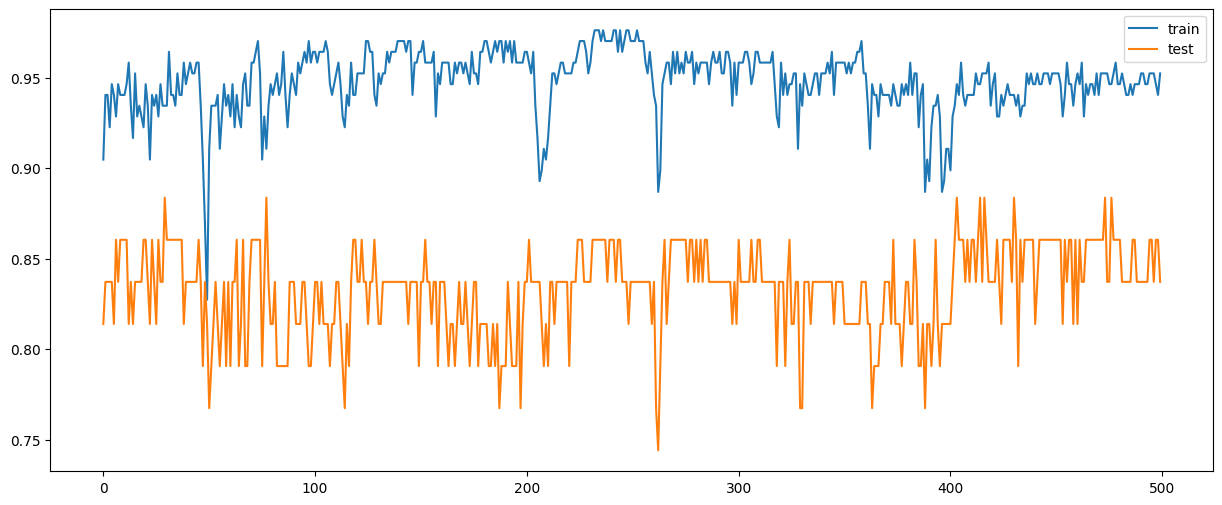

In [59]:
# Now let's plot the accuracy and val_accuracy to understand what happened
plt.figure(figsize=(15,6))
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='test')
plt.legend()
plt.show()

In [60]:
# As we can see that the loss of the validation set at some point afterwards is increasing that to jaggered in nature 
# Also note that the loss is greatly of the validation set meaning that the model is overfitting which can also be seen in the accuracy
# comparission of both as above.

In [61]:
# This was the whole process without dropping nodes, now what if we drop nodes randomly ?

In [62]:
# The whole process remaings same but in the building phase we add Dropout value to set how the ratio of nodes to be dropped out for the layer above
model = Sequential()

model.add(Input(shape=(X.shape[1],)))

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1,activation='sigmoid'))

In [63]:
# Now lets check the model summary for this
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# Now we do the rest steps as it is 
adam = Adam(learning_rate=0.001) # <-- This was also the cause of jaggerdness
model.compile(loss='binary_crossentropy',optimizer=adam,metrics=['accuracy'])

In [65]:
history = model.fit(X_train,y_train,epochs=500,validation_data=(X_test,y_test),verbose=1)

Epoch 1/500


6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 187ms/step - accuracy: 0.6905 - loss: 0.6809 - val_accuracy: 0.7907 - val_loss: 0.6571
Epoch 2/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8393 - loss: 0.6453 - val_accuracy: 0.7907 - val_loss: 0.6245
Epoch 3/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8333 - loss: 0.6102 - val_accuracy: 0.7907 - val_loss: 0.5909
Epoch 4/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8512 - loss: 0.5722 - val_accuracy: 0.7674 - val_loss: 0.5533
Epoch 5/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8393 - loss: 0.5263 - val_accuracy: 0.7907 - val_loss: 0.5122
Epoch 6/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8690 - loss: 0.4825 - val_accuracy: 0.7442 - val_loss: 0.4707
Epoch 7/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8690 - loss: 0.4323 - val_accuracy: 0.7674 - val_loss: 0.4368
Epoch 8/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8929 - loss: 0.3754 - val_accuracy: 0.7907 - val_loss: 0.4096
Epo

In [66]:
# Now let's plot all the graphs again to check for any improvements

28125/28125 ━━━━━━━━━━━━━━━━━━━━ 47s 2ms/step


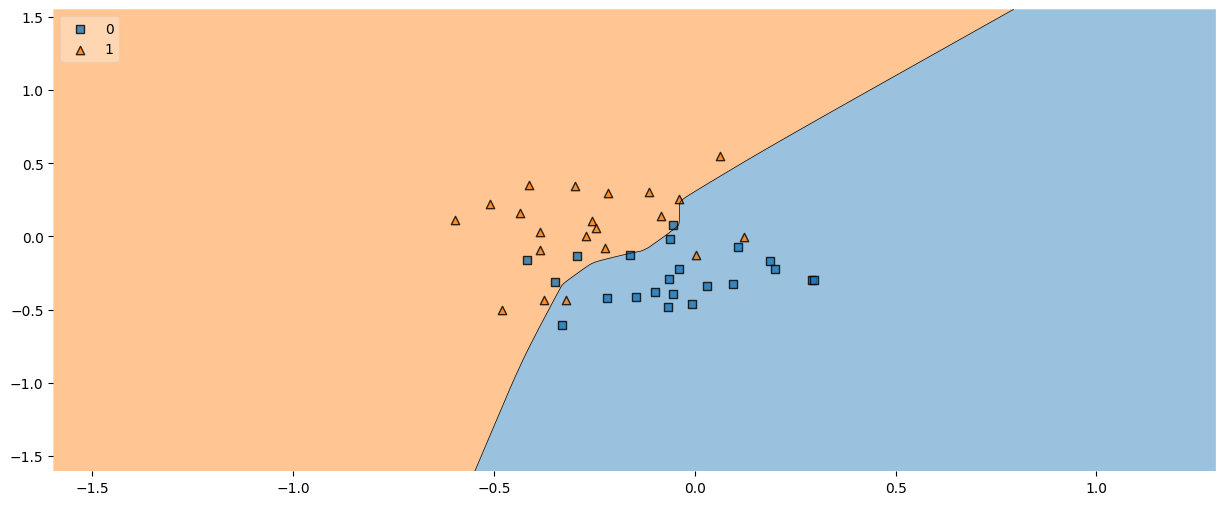

In [67]:
plt.figure(figsize=(15,6))
plot_decision_regions(X_test.to_numpy(),y_test.to_numpy(),clf=model,legend=2)
plt.show()

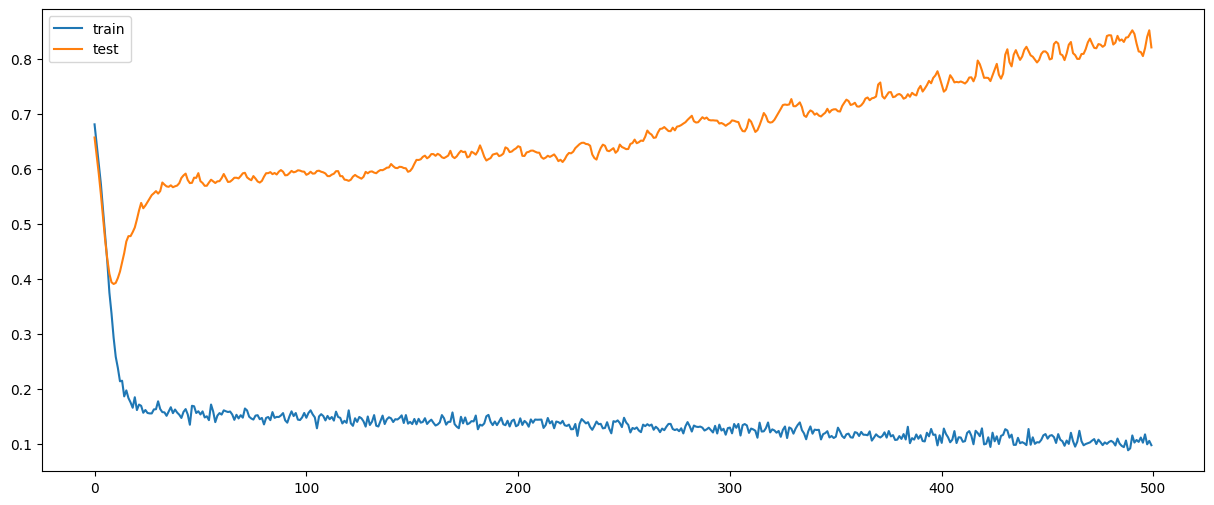

In [68]:
plt.figure(figsize=(15,6))
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

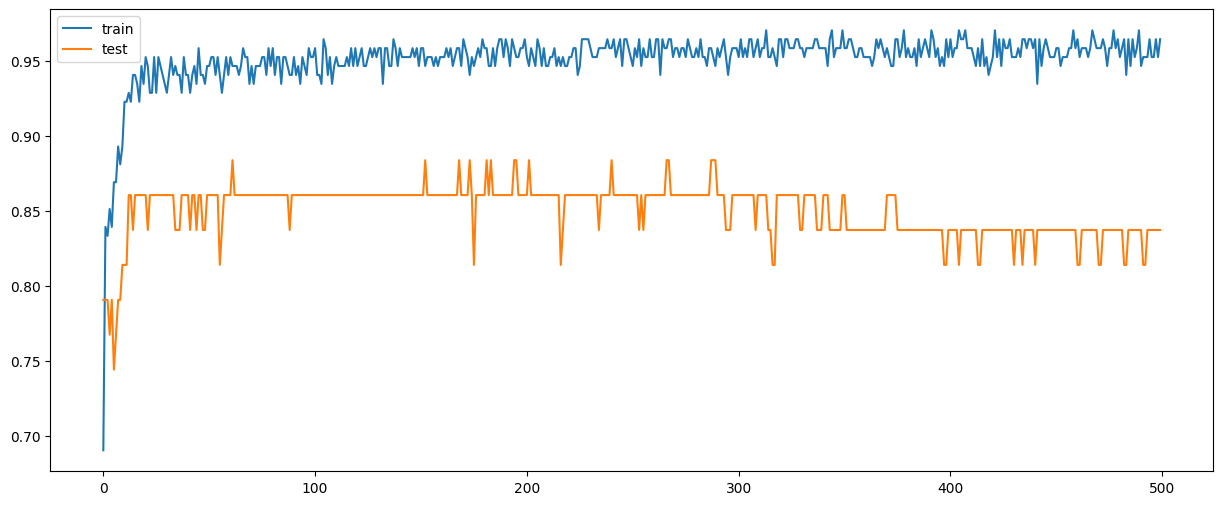

In [69]:
plt.figure(figsize=(15,6))
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='test')
plt.legend()
plt.show()

In [70]:
# In the end after experimenting I found out that for higher values the boundary formation is inaccurate and underfitting , so for now 
# I would go with 0.2 as the optimum value